# EDA — Fake.br-Corpus e Fakepedia

Análise exploratória das duas bases de notícias em português usadas no desafio.

- **Fake.br-Corpus** (NILC/USP): 3.600 notícias falsas pareadas com 3.600 verdadeiras
  sobre o mesmo assunto, com 21 métricas linguísticas por texto.
- **Fakepedia**: boatos checados pelo Boatos.org (só a classe *fake*), com título,
  texto do boato e categoria.

Para gerar os dados: `make dados` (ou `bash scripts/baixar_dados.sh` seguido de
`python scripts/preparar_dados.py`). O notebook lê `data/processed/dataset.jsonl` e,
nas seções de qualidade, os brutos de `data/raw/`.

In [1]:
import json
import re
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RAW = RAIZ / "data" / "raw"
PROCESSED = RAIZ / "data" / "processed" / "dataset.jsonl"

CORES = {"fake": "#eb6834", "true": "#2a78d6", "fakepedia": "#1baf7a"}
TINTA, TINTA_2 = "#0b0b0b", "#52514e"
plt.rcParams.update({
    "figure.dpi": 110, "figure.figsize": (9, 4), "axes.spines.top": False,
    "axes.spines.right": False, "axes.grid": True, "grid.color": "#e6e5e0",
    "grid.linewidth": 0.8, "axes.axisbelow": True, "axes.edgecolor": "#b8b7b0",
    "axes.labelcolor": TINTA_2, "xtick.color": TINTA_2, "ytick.color": TINTA_2,
    "axes.titlesize": 12, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "legend.frameon": False,
})
pd.set_option("display.max_colwidth", 120)

df = pd.read_json(PROCESSED, lines=True)
df["data"] = pd.to_datetime(df["data"])
df["texto"] = df["texto"].fillna("")
df["n_palavras"] = df["texto"].str.split().str.len()
fb = df[df.base == "fakebr"].copy()
fp = df[df.base == "fakepedia"].copy()
df.groupby(["base", "rotulo"]).size().rename("noticias").to_frame()

noticias
base      rotulo          
fakebr    fake        3600
          true        3600
fakepedia fake        5201

## 1. Estrutura e completude

In [2]:
campos = ["titulo", "texto", "categoria", "data", "autor", "url", "metricas"]
preenchido = (
    df.assign(texto=df.texto.replace("", None))
    .groupby(["base", "rotulo"])[campos]
    .agg(lambda s: s.notna().mean())
    .mul(100).round(1)
)
preenchido

titulo  texto  categoria   data  autor    url  metricas
base      rotulo                                                         
fakebr    fake       0.0  100.0      100.0  100.0    2.0  100.0     100.0
          true       0.0  100.0      100.0   99.9   98.0  100.0     100.0
fakepedia fake     100.0   87.8       99.9    0.0    0.0  100.0       0.0

O Fake.br não traz título separado: a notícia inteira fica em `texto`. O Fakepedia
não tem data nem autor, e cerca de 12% dos boatos não trazem o texto, só o título.
O autor aparece quase só nas notícias verdadeiras do Fake.br (ver seção 5).

## 2. Qualidade dos brutos

### 2.1 Fakepedia: linhas duplicadas

In [3]:
fp_raw = pd.read_csv(RAW / "fakepedia-corpus-v1.csv", sep=";")
fp_raw["url_review"] = fp_raw.url_review.str.strip()
resumo = pd.Series({
    "linhas no CSV": len(fp_raw),
    "URLs únicas": fp_raw.url_review.nunique(),
    "linhas 100% duplicadas": fp_raw.duplicated().sum(),
    "linhas sem texto (message)": fp_raw.message.isna().sum(),
    "linhas sem source": fp_raw.source.isna().sum(),
    "valores de type": fp_raw.type.unique().tolist(),
})
resumo.to_frame("valor")

,valor
linhas no CSV,8517
URLs únicas,5201
linhas 100% duplicadas,3316
linhas sem texto (message),923
linhas sem source,70
valores de type,[fake]


In [4]:
fp_raw.groupby("url_review").size().value_counts().sort_index().rename_axis("cópias por URL").to_frame("URLs")

,URLs
cópias por URL,
1,3436
2,281
3,1417
4,67


**39% das linhas do CSV são cópias exatas** (cada boato aparece 1 a 4 vezes). O
`preparar_dados.py` deduplica por `url_review` e mantém 5.201 boatos. Sem essa limpeza,
qualquer divisão treino/teste vazaria exemplos idênticos entre os conjuntos. As 70
linhas sem `source` também são do Boatos.org, como mostra a URL.

### 2.2 Fake.br: datas e métricas

In [5]:
datas_brutas = []
for pasta in (RAW / "Fake.br-Corpus" / "full_texts").glob("*-meta-information"):
    for arq in pasta.glob("*.txt"):
        datas_brutas.append(arq.read_text(encoding="utf-8-sig").split("\n")[3])
formatos = pd.Series([re.sub(r"\d", "9", d.strip()) for d in datas_brutas]).value_counts()
print(f"{len(formatos)} formatos distintos de data; os mais comuns:")
formatos.head(8).to_frame("arquivos")

19 formatos distintos de data; os mais comuns:


,arquivos
99/99/9999,3479
99/99/9999 99h99,2162
9999-99-99,263
99 de março de 9999,228
99 de fevereiro de 9999,121
99 de janeiro de 9999,108
9/9/9999,100
99 de setembro de 9999,97


In [6]:
met = pd.json_normalize(fb.metricas).set_index(fb.index)
fbm = pd.concat([fb[["rotulo", "par_id", "categoria"]], met], axis=1)
print("datas não interpretáveis:", fb.data.isna().sum())
fbm.isna().groupby(fbm.rotulo).sum().loc[:, lambda t: t.sum() > 0]

datas não interpretáveis: 3


,n_links
rotulo,
fake,0
true,1393


As datas vêm em cerca de 20 formatos (`dd/mm/aaaa`, `aaaa-mm-dd`, `dd de mês de aaaa`,
alguns em `m/d/aaaa` e 3 com ano digitado errado, como `0201`). Todas foram
normalizadas para ISO, exceto essas 3. A métrica `n_links` vem como `None` em 1.393
notícias verdadeiras e em nenhuma falsa, então **não serve como feature**: o simples
fato de ela estar ausente já indica a classe.

## 3. Categorias

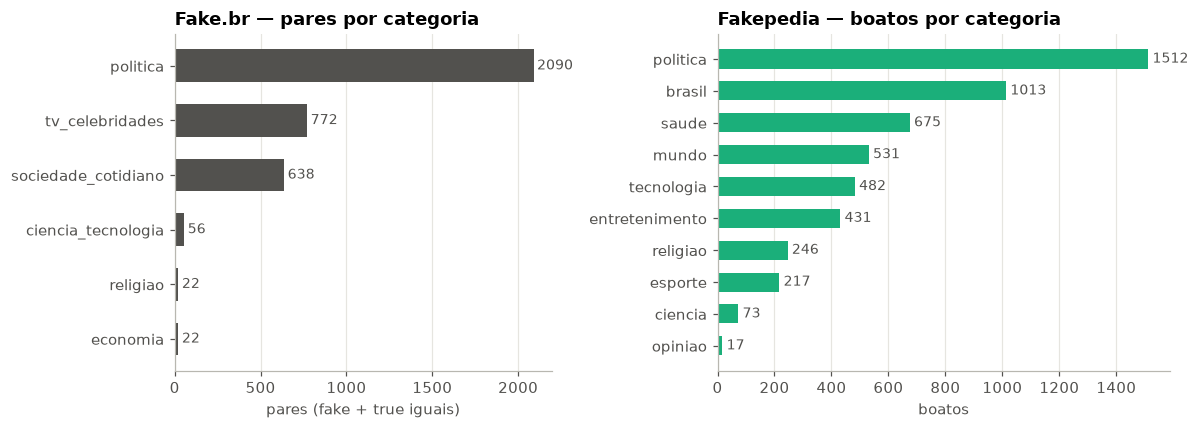

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), gridspec_kw={"width_ratios": [1, 1.2]})
cat_fb = fb[fb.rotulo == "fake"].categoria.value_counts()
axes[0].barh(cat_fb.index[::-1], cat_fb.values[::-1], color=TINTA_2, height=0.6)
axes[0].set_title("Fake.br — pares por categoria")
axes[0].set_xlabel("pares (fake + true iguais)")
for y, v in enumerate(cat_fb.values[::-1]):
    axes[0].text(v + 20, y, f"{v}", va="center", color=TINTA_2, fontsize=9)

cat_fp = fp.categoria.value_counts()
axes[1].barh(cat_fp.index[::-1], cat_fp.values[::-1], color=CORES["fakepedia"], height=0.6)
axes[1].set_title("Fakepedia — boatos por categoria")
axes[1].set_xlabel("boatos")
for y, v in enumerate(cat_fp.values[::-1]):
    axes[1].text(v + 15, y, f"{v}", va="center", color=TINTA_2, fontsize=9)
for ax in axes:
    ax.grid(axis="y", visible=False)
fig.tight_layout()

No Fake.br, cada notícia falsa tem uma verdadeira da mesma categoria, então a
distribuição é idêntica entre as classes. Ela é, porém, bem concentrada:
**58% é política** e economia, religião e ciência somam menos de 3%. O Fakepedia é
mais variado, com saúde, tecnologia, mundo e entretenimento, e as categorias das duas
bases não coincidem (`sociedade_cotidiano` × `brasil`, `tv_celebridades` ×
`entretenimento`). Se as bases forem combinadas, é preciso mapear uma taxonomia comum.

## 4. Período de publicação (Fake.br)

,min,25%,50%,75%,max
rotulo,,,,,
fake,2012-09-13 00:00:00,2016-06-07 12:00:00,2016-12-15 00:00:00,2017-06-29 12:00:00,2018-02-02 00:00:00
true,2009-06-01 00:00:00,2017-05-18 00:00:00,2017-10-10 00:00:00,2018-01-24 00:00:00,2018-07-23 00:00:00


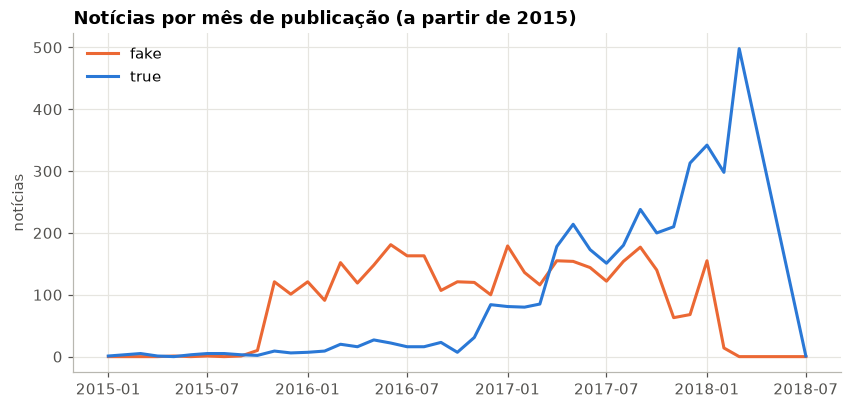

In [8]:
mes = fb.dropna(subset=["data"]).assign(mes=lambda d: d.data.dt.to_period("M").dt.to_timestamp())
serie = mes.groupby(["mes", "rotulo"]).size().unstack(fill_value=0)
serie = serie[serie.index >= "2015-01-01"]
fig, ax = plt.subplots()
for rot in ["fake", "true"]:
    ax.plot(serie.index, serie[rot], color=CORES[rot], lw=2, label=rot)
ax.set_title("Notícias por mês de publicação (a partir de 2015)")
ax.set_ylabel("notícias")
ax.legend(loc="upper left")
fb.groupby("rotulo").data.describe()[["min", "25%", "50%", "75%", "max"]]

As falsas se concentram entre 2016 e 2017. As verdadeiras foram coletadas depois,
buscando o mesmo assunto, e por isso **tendem a ser mais recentes** (mediana em
out/2017 contra dez/2016 nas falsas, cerca de 10 meses depois), com uma cauda que chega
a 2009. Para um
classificador, a data é portanto um atalho espúrio e deve ficar fora das features.

## 5. Fontes e autores (Fake.br)

In [9]:
fb["dominio"] = fb.url.str.extract(r"https?://(?:www\d?\.)?([^/]+)")[0]
fb["site"] = fb.dominio.str.replace(r"^[a-z-]+\.(estadao\.com\.br)$", r"\1", regex=True)
top = (fb.groupby("rotulo").site.value_counts(normalize=True).mul(100).round(1)
       .groupby(level=0).head(5).rename("% da classe").to_frame())
top

% da classe
rotulo site                                        
fake   diariodobrasil.org                      92.7
       afolhabrasil.com.br                      4.8
       thejornalbrasil.com.br                   1.8
       ceticismopolitico.com                    0.4
       topfivetv.com                            0.2
true   g1.globo.com                            63.9
       estadao.com.br                          33.4
       folha.uol.com.br                         2.5
       territorioeldorado.limao.com.br          0.1
       f5.folha.uol.com.br                      0.1

In [10]:
fb.assign(tem_autor=fb.autor.notna()).groupby("rotulo").agg(
    pct_com_autor=("tem_autor", lambda s: round(100 * s.mean(), 1)),
    autores_distintos=("autor", "nunique"),
)

,pct_com_autor,autores_distintos
rotulo,,
fake,2.0,5
true,98.0,1415


**Cada classe vem de um conjunto de sites diferente.** 93% das falsas saíram de um
único site (diariodobrasil.org), enquanto as verdadeiras vêm de G1, Estadão e Folha.
Autor praticamente só existe nas verdadeiras. Qualquer resquício de fonte no texto
(assinatura, "Por G1", nome de colunista) vira um atalho para o modelo, que acaba
aprendendo "qual site" em vez de "o que é falso".

## 6. Tamanho dos textos

mean    25%    50%     75%     max
base      rotulo                                      
fakebr    fake     186.0  115.0  157.0   224.0  2288.0
          true    1100.0  642.0  918.0  1416.0  7517.0
fakepedia fake     119.0   34.0   77.0   161.0  2020.0

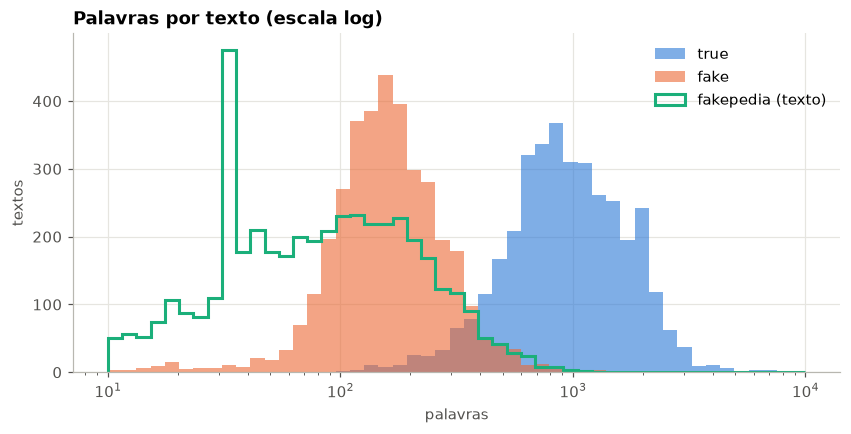

In [11]:
fig, ax = plt.subplots()
bins = np.logspace(1, 4, 50)
for rot in ["true", "fake"]:
    ax.hist(fb[fb.rotulo == rot].n_palavras, bins=bins, color=CORES[rot], alpha=0.6, label=rot)
ax.hist(fp[fp.texto != ""].n_palavras, bins=bins, histtype="step", lw=2,
        color=CORES["fakepedia"], label="fakepedia (texto)")
ax.set_xscale("log")
ax.set_title("Palavras por texto (escala log)")
ax.set_xlabel("palavras")
ax.set_ylabel("textos")
ax.legend()
df[df.texto != ""].groupby(["base", "rotulo"]).n_palavras.describe()[["mean", "25%", "50%", "75%", "max"]].round(0)

In [12]:
par = fb.pivot(index="par_id", columns="rotulo", values="n_palavras")
print(f"verdadeira maior que a falsa em {100 * (par.true > par.fake).mean():.1f}% dos pares")
print(f"razão mediana true/fake: {(par.true / par.fake).median():.1f}x")

verdadeira maior que a falsa em 98.2% dos pares
razão mediana true/fake: 6.1x


Mesmo tratando do mesmo assunto, **a notícia verdadeira é em geral bem mais longa
que a falsa**. Só o tamanho já separa boa parte das classes. Por isso o corpus traz
`size_normalized_texts/`, em que cada par é truncado para o tamanho do menor, e é
essa a versão que convém usar para treinar e avaliar. Os textos do Fakepedia são mais
curtos ainda (mediana abaixo de 100 palavras): em geral é a mensagem que circulou no
WhatsApp ou nas redes, não uma matéria.

## 7. Métricas linguísticas (Fake.br)

O corpus traz 21 métricas por texto. As contagens (verbos, adjetivos, maiúsculas…)
são divididas pelo número de palavras, porque em valor absoluto só repetiriam o efeito
do tamanho visto na seção 6. Cada métrica é resumida pelo **d de Cohen** (diferença de
médias fake − true dividida pelo desvio padrão combinado): valores positivos indicam
métrica maior nas falsas, e |d| ≥ 0,8 costuma ser lido como efeito grande.

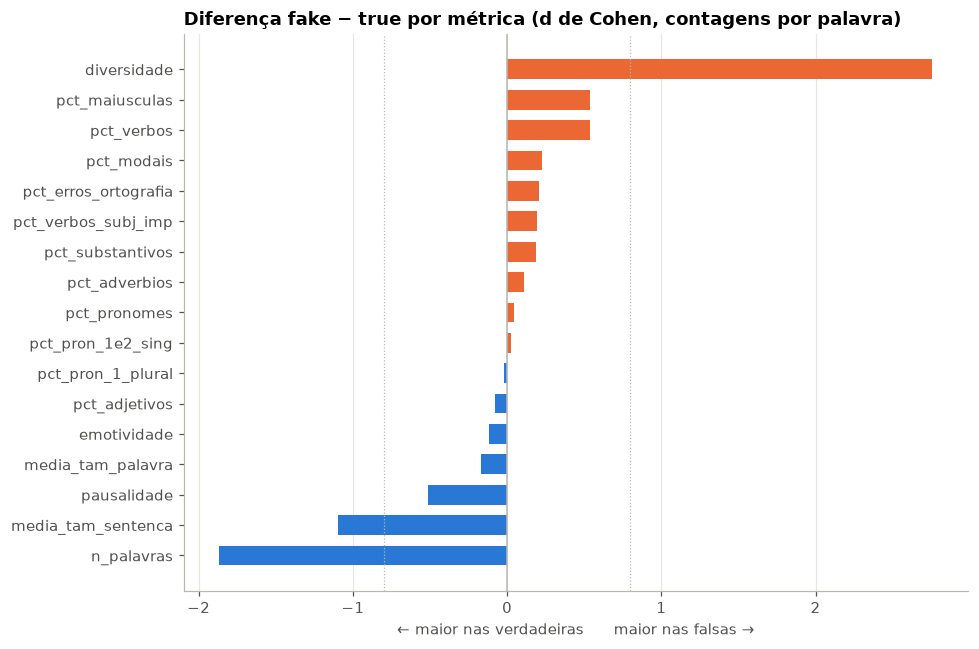

In [13]:
CONTAGENS = ["n_types", "n_maiusculas", "n_verbos", "n_verbos_subj_imp", "n_substantivos",
             "n_adjetivos", "n_adverbios", "n_modais", "n_pron_1e2_sing", "n_pron_1_plural",
             "n_pronomes"]
estilo = fbm[["rotulo", "n_palavras", "pausalidade", "media_tam_sentenca", "media_tam_palavra",
              "pct_erros_ortografia", "emotividade", "diversidade"]].copy()
for c in CONTAGENS:
    estilo[c.replace("n_", "pct_", 1)] = 100 * fbm[c] / fbm.n_palavras
estilo = estilo.drop(columns="pct_types")  # igual a diversidade (types / palavras)
metricas = [c for c in estilo.columns if c != "rotulo"]

def cohen_d(a, b):
    sp = np.sqrt(((len(a) - 1) * a.var() + (len(b) - 1) * b.var()) / (len(a) + len(b) - 2))
    return (a.mean() - b.mean()) / sp
fk, tr = estilo[estilo.rotulo == "fake"], estilo[estilo.rotulo == "true"]
efeito = pd.Series({m: cohen_d(fk[m], tr[m]) for m in metricas}).sort_values()

fig, ax = plt.subplots(figsize=(9, 6))
cores = [CORES["fake"] if v > 0 else CORES["true"] for v in efeito]
ax.barh(efeito.index, efeito.values, color=cores, height=0.65)
ax.axvline(0, color="#b8b7b0", lw=1)
for x in (-0.8, 0.8):
    ax.axvline(x, color="#b8b7b0", lw=0.8, ls=":")
ax.set_title("Diferença fake − true por métrica (d de Cohen, contagens por palavra)")
ax.set_xlabel("← maior nas verdadeiras      maior nas falsas →")
ax.grid(axis="y", visible=False)
fig.tight_layout()

In [14]:
tabela = estilo.groupby("rotulo")[metricas].median().T.round(3)
tabela["d_cohen"] = efeito.round(2)
tabela.sort_values("d_cohen", key=abs, ascending=False)

rotulo,fake,true,d_cohen
diversidade,0.676,0.472,2.76
n_palavras,157.000,922.000,-1.87
media_tam_sentenca,15.000,20.586,-1.09
pct_maiusculas,1.587,0.964,0.54
pct_verbos,16.770,15.010,0.54
pausalidade,2.340,2.960,-0.51
pct_modais,2.200,2.047,0.23
pct_erros_ortografia,0.000,0.001,0.21
pct_verbos_subj_imp,0.549,0.537,0.19
pct_substantivos,29.268,28.854,0.19


Os dois maiores efeitos ainda são **tamanho disfarçado**. A `diversidade` é
types/palavras (TTR), que cai naturalmente em textos longos, e o tamanho de sentença
acompanha o estilo de matéria longa das verdadeiras. Descontado isso, sobram
diferenças **moderadas** (|d| ≈ 0,5): as falsas usam mais CAIXA ALTA (1,6% × 1,0% das
palavras), mais verbos e menos pausas (vírgulas e pontos por sentença). Emotividade,
adjetivos, pronomes e erros de ortografia **praticamente não diferem**. A intuição de
que fake news são "mais emotivas" não se confirma nesta base. Para o jogo, dá para usar
CAIXA ALTA como dica; emotividade não.

## 8. Artefatos de formatação

In [15]:
def forma(texto):
    primeira, _, resto = texto.partition("\n")
    return pd.Series({
        "1ª linha curta (<200 car.)": len(primeira) < 200 and bool(resto.strip()),
        "tem quebra de linha": "\n" in texto,
        "tem URL no texto": bool(re.search(r"https?://|www\.", texto)),
        "termina sem pontuação": not texto.rstrip()[-1:] in ".!?\"”)",
    })
fb.join(fb.texto.apply(forma)).groupby("rotulo")[[
    "1ª linha curta (<200 car.)", "tem quebra de linha", "tem URL no texto", "termina sem pontuação"
]].mean().mul(100).round(1)

,1ª linha curta (<200 car.),tem quebra de linha,tem URL no texto,termina sem pontuação
rotulo,,,,
fake,2.4,7.3,0.1,22.3
true,8.3,8.8,3.2,17.1


In [16]:
for rot in ["fake", "true"]:
    print(f"--- {rot} (par 1) ---")
    print(fb[(fb.rotulo == rot) & (fb.par_id == 1)].texto.iloc[0][:350], "\n")

--- fake (par 1) ---
Kátia Abreu diz que vai colocar sua expulsão em uma moldura, mas não para de reclamar.	

A senadora Kátia Abreu (sem partido-TO) disse que sua expulsão do PMDB foi resultado de uma ação da cúpula atual da legenda que, segundo ela, é oportunista.

“Amanhã eu vou botar numa moldura dourada a minha expulsão, porque das mãos de onde veio, é um atestado 

--- true (par 1) ---
O Podemos decidiu  expulsar o deputado federal Carlos Gaguim do partido após a Polícia Federal fazer buscas a apreensões no gabinete dele na Câmara. Com isso, a legenda abre espaço para receber a senadora expulsa pelo PMDB, Katia Abreu. Por meio de nota, a legenda informou que o afastamento do parlamentar já era algo acordado entre os filiados da s 



A formatação é parecida entre as classes: pouquíssimos textos têm quebra de linha
(o par 1 acima, com a manchete separada, é exceção) e só 10 verdadeiras vinham com BOM
UTF-8, que o preparo remove. O sinal mais claro é **URL dentro do texto**, que aparece
em 3,2% das verdadeiras e quase nunca nas falsas. É um sinal pequeno, mas totalmente
espúrio, então convém remover URLs e normalizar espaços antes de treinar.

## 9. Vocabulário característico

Palavras mais típicas de cada classe pelo *log-odds ratio* com prior de Dirichlet
informativo (Monroe et al., 2008). O método penaliza palavras raras e não depende de
lista de stopwords.

In [17]:
TOKEN = re.compile(r"[a-záàâãéêíóôõúüç]+")
def contar(textos):
    c = Counter()
    for t in textos:
        c.update(TOKEN.findall(t.lower()))
    return c

def log_odds(ca, cb, alpha=0.01, min_freq=20):
    fundo = ca + cb
    a0 = alpha * sum(fundo.values())
    na, nb = sum(ca.values()), sum(cb.values())
    linhas = []
    for w, f in fundo.items():
        if f < min_freq:
            continue
        aw = alpha * f
        ya, yb = ca[w], cb[w]
        delta = np.log((ya + aw) / (na + a0 - ya - aw)) - np.log((yb + aw) / (nb + a0 - yb - aw))
        var = 1 / (ya + aw) + 1 / (yb + aw)
        linhas.append((w, delta / np.sqrt(var), ya, yb))
    return pd.DataFrame(linhas, columns=["palavra", "z", "freq_a", "freq_b"]).set_index("palavra")

lo = log_odds(contar(fb[fb.rotulo == "fake"].texto), contar(fb[fb.rotulo == "true"].texto))
pd.concat({
    "mais típicas de FAKE": lo.nlargest(20, "z").reset_index()[["palavra", "z"]],
    "mais típicas de TRUE": lo.nsmallest(20, "z").reset_index()[["palavra", "z"]],
}, axis=1).round(1)

mais típicas de FAKE       mais típicas de TRUE      
                palavra     z              palavra     z
0                 dilma  46.1                  mas -21.0
1                  lula  33.9              segundo -18.3
2                 vídeo  30.6                nesta -15.3
3            jornalista  26.9                feira -14.6
4               petista  24.7                   em -14.0
5                 globo  24.4                    g -13.2
6           impeachment  22.3                    à -13.0
7             bolsonaro  22.2                   de -12.3
8               através  21.3             tribunal -12.3
9                  está  20.5                   no -12.0
10               jornal  20.3                  ano -11.9
11               poderá  20.1                    h -11.5
12                 moro  19.7                    a -11.5
13                disse  19.1                  por -11.5
14                redes  18.9                 como -11.1
15              matéria  18.8              decisão -10.0
16               coréia  18.8               região -10.0
17         apresentador  18.2                terça -10.0
18                  eua  18.2                  das  -9.6
19                   pt  18.1                  rio  -9.5

As falsas concentram nomes de políticos (Dilma, Lula, Bolsonaro, Moro, PT) e
referências à própria mídia ("vídeo", "jornalista", "Globo", "matéria", "redes"). Nas
verdadeiras dominam palavras funcionais (reflexo dos textos mais longos) e o registro de
agência, como "segundo", "nesta", "terça-feira" e "decisão". Os tokens `g` e `h` vêm
de "G1" e de horários ("14h"): **são traços da fonte** e devem ser tratados antes de
treinar (ver seção 5).

## 10. Fakepedia em detalhe

In [18]:
fp["n_car_titulo"] = fp.titulo.str.len()
fp["tem_texto"] = fp.texto != ""
fp.groupby("categoria").agg(
    boatos=("id", "size"),
    pct_com_texto=("tem_texto", lambda s: round(100 * s.mean(), 1)),
    car_titulo_mediana=("n_car_titulo", "median"),
    palavras_texto_mediana=("n_palavras", lambda s: s[s > 0].median()),
).sort_values("boatos", ascending=False)

,boatos,pct_com_texto,car_titulo_mediana,palavras_texto_mediana
categoria,,,,
politica,1512,89.0,67.0,68.0
brasil,1013,89.3,66.0,77.0
saude,675,91.0,69.0,109.5
mundo,531,87.6,68.0,67.0
tecnologia,482,85.1,67.0,92.0
entretenimento,431,84.2,65.0,55.0
religiao,246,87.8,64.0,122.0
esporte,217,80.6,67.0,63.0
ciencia,73,83.6,72.0,82.0


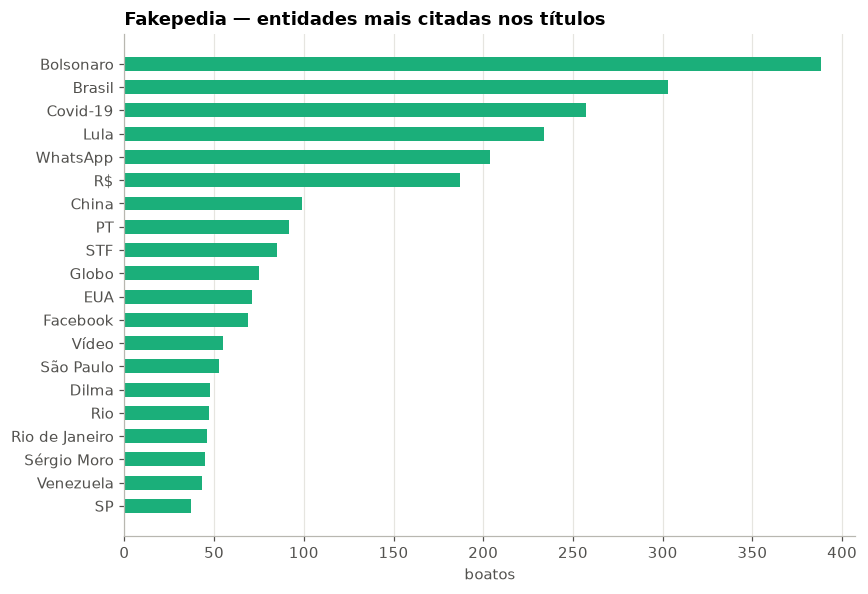

In [19]:
entidades = Counter()
for bruto in fp_raw.drop_duplicates("url_review").entities:
    entidades.update(e.strip() for e in bruto.strip("[]").split(",") if e.strip())
top_ent = pd.Series(dict(entidades.most_common(20)))
fig, ax = plt.subplots(figsize=(8, 5.5))
ax.barh(top_ent.index[::-1], top_ent.values[::-1], color=CORES["fakepedia"], height=0.6)
ax.set_title("Fakepedia — entidades mais citadas nos títulos")
ax.set_xlabel("boatos")
ax.grid(axis="y", visible=False)
fig.tight_layout()

In [20]:
fp.sample(8, random_state=7)[["categoria", "titulo"]]

,categoria,titulo
9496,brasil,Casas Bahia anuncia que não venderá a prazo para eleitores de Ciro Gomes
9341,politica,Voto parcial: quem votar só para presidente e branco nos outros candidatos terá voto anulado
10523,politica,"Túlio Gadêlha, namorado de Fátima Bernardes, comemora aprovação do fundo eleitoral e derrubada de veto de Bolsonaro"
10027,entretenimento,Regina Duarte diz que Brasil inventou a prisão esportiva: polícia prende e STF solta
10086,mundo,Maduro mandou prender equipe médica que recebeu ajuda humanitária
11201,saude,Dexametasona é a cura para a Covid-19 e previne o coronavírus
7602,politica,Roberto Requião recebe pensão de R$ 452 mil por mês
9949,politica,Menina se recusa a cumprimentar Bolsonaro em cerimônia no Planalto


Os títulos do Fakepedia são **afirmações curtas e autocontidas** (mediana
de 67 caracteres), escritas pelo Boatos.org para descrever o boato. É o formato ideal
para uma pergunta do jogo ("verdadeiro ou falso?"). Como a base só tem a classe
*fake*, ela não serve sozinha para treinar um classificador: precisa de um par
verdadeiro vindo de outra fonte, ou o uso fica restrito ao conteúdo do jogo.

A base não tem data, mas as entidades revelam a época: Covid-19, WhatsApp e Bolsonaro
no topo mostram boatos até pelo menos 2020, **anos depois do Fake.br** (2016–2018). Um
modelo treinado no Fake.br nunca viu esses temas, e o Fakepedia é um bom teste de
generalização no tempo.

## 11. Conclusões e recomendações

**Qualidade**
- Fakepedia: deduplicar por URL (39% das linhas são cópias), o que já está no preparo.
  O Fake.br é balanceado (3.600 × 3.600), e o Fakepedia tem só a classe *fake*.
  12% dos boatos têm só título.
- Fake.br: datas em cerca de 20 formatos (normalizadas) e `n_links` ausente só nas
  verdadeiras, o que a torna inutilizável como feature.

**Vieses e atalhos que um modelo aprenderia**
1. **Tamanho**: a verdadeira é a mais longa em 98% dos pares (6× na mediana). Use
   `size_normalized_texts` ou normalize o tamanho.
2. **Fonte**: cada classe vem de sites diferentes, e o autor só existe nas
   verdadeiras. Não use URL, domínio ou autor e limpe assinaturas do texto.
3. **Formatação e marcas de fonte**: URLs no texto quase só nas verdadeiras, além de
   "G1" e horários. Remova URLs e assinaturas e normalize os espaços.
4. **Tempo**: as verdadeiras são mais recentes, então a data não entra como feature.
5. **Tema**: 58% é política, e o desempenho em saúde ou ciência não é garantido.

**Avaliação**
- Dividir treino e teste **por par** (`par_id`) no Fake.br, para que o par de uma
  notícia não caia do outro lado da divisão.
- Medir também em dados fora da distribuição, por exemplo treinar no Fake.br e testar
  nos boatos do Fakepedia (classe única: acompanhar o recall de *fake*).

**Para o jogo**
- Títulos do Fakepedia são bons candidatos a questões *fake*, com categoria e link
  de checagem do Boatos.org para mostrar na explicação da resposta.
- De estilo, só a CAIXA ALTA e o menor número de pausas diferem de fato. Emotividade e
  adjetivos não diferem nesta base, então não convém ensinar isso como "dica" sem
  outra evidência.